# SupportIQ v8 — AI Customer Support Agent

**NovaTech Solutions**

### What's new in v8 (merged from corrective RAG + self RAG notebooks):
- `is_relevant` — per-doc relevance filter before generation (from V7)
- `is_sup` — grounding verification after generation (from V7)
- `revise_answer` — strict revision loop if answer is not grounded (from V7)
- `is_use` — usefulness check after grounding passes (from V7)
- `rewrite_question` — rewrites retrieval query if answer is not useful (from V7)
- Replaces old `quality_check` + `regenerate_response` with this principled 3-stage verification

### Full graph flow:
```
START
  → categorize
  → analyze_sentiment
  → route_query
      → escalate → create_ticket → END
      → retrieve_context
          → is_relevant (filter docs)
          → handle_technical / handle_billing / handle_general
          → is_sup (grounding check)
              → fully_supported → is_use
              → partially/no_support → revise_answer → is_sup (loop)
          → is_use (usefulness check)
              → useful → create_ticket → END
              → not_useful → rewrite_question → retrieve_context (loop)
              → give_up → create_ticket → END
```

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from typing import TypedDict, List, Literal
from pydantic import BaseModel, Field
from datetime import datetime
import sqlite3
import uuid
import os

from dotenv import load_dotenv
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import pandas as pd

load_dotenv()

print("Imports done ✅")

Imports done ✅


In [2]:
# ── LLM and parser ────────────────────────────────────────────────────────────
llm    = ChatOpenAI(model="gpt-4o-mini", temperature=0)
parser = StrOutputParser()

print("LLM initialized ✅")

LLM initialized ✅


In [3]:
# ── Ticket database ───────────────────────────────────────────────────────────
DB_PATH = "novatech_tickets.db"

def init_tickets_db():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS tickets (
            ticket_id      TEXT PRIMARY KEY,
            created_at     TEXT,
            category       TEXT,
            sentiment      TEXT,
            confidence     REAL,
            issup          TEXT,
            isuse          TEXT,
            rewrite_tries  INTEGER,
            revise_tries   INTEGER,
            query          TEXT,
            response       TEXT,
            status         TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("Tickets database initialized ✅")


def get_all_tickets() -> list:
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    cursor = conn.execute("SELECT * FROM tickets ORDER BY created_at DESC")
    tickets = [dict(row) for row in cursor.fetchall()]
    conn.close()
    return tickets


init_tickets_db()

Tickets database initialized ✅


In [4]:
# ── Knowledge base — load NovaTech PDFs ───────────────────────────────────────
PDF_PATHS = [
    "./docs/novatech_technical_faq.pdf",
    "./docs/novatech_billing_faq.pdf",
    "./docs/novatech_general_faq.pdf",
]

all_docs = []
for path in PDF_PATHS:
    docs = PyMuPDFLoader(path).load()
    # Clean text to avoid unicode issues from PDF extraction
    for d in docs:
        d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")
    all_docs.extend(docs)
    print(f"Loaded {len(docs)} pages from {path}")

chunks = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
).split_documents(all_docs)

print(f"\nTotal chunks: {len(chunks)}")

embeddings  = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever   = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

print("Knowledge base ready ✅")

Loaded 2 pages from ./docs/novatech_technical_faq.pdf
Loaded 2 pages from ./docs/novatech_billing_faq.pdf
Loaded 2 pages from ./docs/novatech_general_faq.pdf

Total chunks: 31
Knowledge base ready ✅


In [5]:
# ── State ─────────────────────────────────────────────────────────────────────
class State(TypedDict):
    # Input
    query: str

    # Routing
    category:           str
    confidence:         float
    sentiment:          str
    original_sentiment: str      # preserved before any HITL override

    # RAG
    retrieval_query:    str      # rewritten query for vector search
    docs:               List[Document]   # raw retrieved docs
    relevant_docs:      List[Document]   # after is_relevant filter
    context:            str      # joined relevant docs

    # Generation
    response:           str

    # Verification loops
    issup:              str      # fully_supported | partially_supported | no_support
    evidence:           List[str]
    revise_tries:       int      # how many times revise_answer ran

    isuse:              str      # useful | not_useful
    use_reason:         str
    rewrite_tries:      int      # how many times rewrite_question ran

    # Output
    ticket_id:          str
    ticket:             dict

print("State defined ✅")

State defined ✅


In [6]:
# ── Pydantic schemas ──────────────────────────────────────────────────────────

class QueryCategorySchema(BaseModel):
    category:   Literal["Technical", "Billing", "General"] = Field(
        ..., description="Category of the customer query."
    )
    confidence: float = Field(
        ..., ge=0.0, le=1.0,
        description="Confidence score between 0.0 and 1.0."
    )

class SentimentAnalysisSchema(BaseModel):
    sentiment: Literal["Positive", "Neutral", "Negative"] = Field(
        ..., description="Sentiment of the customer query."
    )

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document contains info that can directly help answer the query."
    )

class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(
        default_factory=list,
        description="Up to 3 short direct quotes from context that support the answer."
    )

class IsUSEDecision(BaseModel):
    isuse:      Literal["useful", "not_useful"]
    use_reason: str = Field(..., description="Short reason in 1 line.")

class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against NovaTech FAQ PDFs."
    )

print("Schemas defined ✅")

Schemas defined ✅


In [7]:
# ── Routing nodes ─────────────────────────────────────────────────────────────

def categorize(state: State) -> dict:
    """Categorize the query into Technical, Billing, or General with confidence."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Categorize the following customer support query into one of: Technical, Billing, General. Provide a confidence score 0.0-1.0."),
        ("user", "Query: {query}")
    ])
    result = (prompt | llm.with_structured_output(QueryCategorySchema)).invoke({"query": state["query"]})
    return {"category": result.category, "confidence": result.confidence}


def analyze_sentiment(state: State) -> dict:
    """Analyze sentiment and preserve original before any HITL override."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Analyze the sentiment of the customer query: Positive, Neutral, or Negative."),
        ("user", "Query: {query}")
    ])
    result = (prompt | llm.with_structured_output(SentimentAnalysisSchema)).invoke({"query": state["query"]})
    return {
        "sentiment":          result.sentiment,
        "original_sentiment": result.sentiment,  # preserved before HITL override
    }


def route_query(state: State) -> str:
    """Route based on sentiment first, then confidence, then category."""
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["confidence"] < 0.7:
        return "retrieve_context"   # low confidence → always retrieve, route by category after
    elif state["category"] == "Technical":
        return "retrieve_context"
    elif state["category"] == "Billing":
        return "retrieve_context"
    else:
        return "retrieve_context"


print("Routing nodes defined ✅")

Routing nodes defined ✅


In [8]:
# ── RAG nodes ─────────────────────────────────────────────────────────────────

def retrieve_context(state: State) -> dict:
    """
    Retrieve relevant chunks from NovaTech knowledge base.
    Uses rewritten retrieval_query if available, otherwise uses raw query.
    """
    q = state.get("retrieval_query") or state["query"]
    docs = retriever.invoke(q)
    return {"docs": docs}


# ── is_relevant ───────────────────────────────────────────────────────────────
is_relevant_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are judging document relevance for a customer support agent.\n"
     "A document is relevant if it discusses the same topic area as the query.\n"
     "It does NOT need to contain the exact answer — that is checked later.\n"
     "Examples:\n"
     "- Technical docs are relevant to login, password, connectivity, integrations.\n"
     "- Billing docs are relevant to refunds, payments, subscriptions, invoices.\n"
     "- General docs are relevant to company info, support hours, privacy, onboarding.\n"
     "When unsure, return is_relevant=true."
    ),
    ("user", "Query:\n{query}\n\nDocument:\n{document}")
])
relevance_llm = llm.with_structured_output(RelevanceDecision)


def is_relevant(state: State) -> dict:
    """Filter retrieved docs — keep only those relevant to the query."""
    relevant_docs = []
    for doc in state.get("docs", []):
        decision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                query=state["query"],
                document=doc.page_content
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)

    context = "\n\n---\n\n".join(d.page_content for d in relevant_docs).strip()
    print(f"  [is_relevant] {len(relevant_docs)}/{len(state.get('docs', []))} docs kept")
    return {"relevant_docs": relevant_docs, "context": context}


def route_after_relevance(state: State) -> str:
    """Route to correct handler if we have relevant docs, else create ticket with no-answer."""
    if state.get("relevant_docs"):
        return state["category"]   # "Technical" | "Billing" | "General"
    return "no_relevant_docs"


print("RAG nodes defined ✅")

RAG nodes defined ✅


In [9]:
# ── Handler nodes ─────────────────────────────────────────────────────────────

HANDLER_SYSTEM = """\
You are a {role} support agent for NovaTech Solutions.
Use the following knowledge base context to answer the query.
If the context is relevant, use it. If not, use your general knowledge.
Do NOT mention that you are reading from a context or knowledge base.
Be specific, actionable, and professional.

Context:
{context}"""


def _handle(state: State, role: str) -> dict:
    prompt = ChatPromptTemplate.from_messages([
        ("system", HANDLER_SYSTEM),
        ("user",   "Query: {query}")
    ])
    response = (prompt | llm | parser).invoke({
        "role":    role,
        "context": state.get("context", ""),
        "query":   state["query"],
    })
    return {"response": response}


def handle_technical(state: State) -> dict:
    return _handle(state, "technical")

def handle_billing(state: State) -> dict:
    return _handle(state, "billing")

def handle_general(state: State) -> dict:
    return _handle(state, "general")

def no_relevant_docs(state: State) -> dict:
    """Fallback when no relevant docs found after filtering."""
    return {
        "response": "I'm sorry, I was unable to find relevant information in our knowledge base to answer your query. Please contact support@novatech.io for further assistance.",
        "issup":    "no_support",
        "isuse":    "not_useful",
    }

def escalate(state: State) -> dict:
    """Escalate to human agent due to negative sentiment."""
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}


print("Handler nodes defined ✅")

Handler nodes defined ✅


In [10]:
# ── Verification nodes (IsSUP + IsUSE + Rewrite) ──────────────────────────────

MAX_REVISE_TRIES  = 2   # max revise_answer iterations
MAX_REWRITE_TRIES = 2   # max rewrite_question iterations


# ── IsSUP ─────────────────────────────────────────────────────────────────────
issup_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are verifying whether the ANSWER is grounded in the CONTEXT.\n"
     "Return issup as one of: fully_supported, partially_supported, no_support.\n\n"
     "fully_supported: Every meaningful claim is explicitly in CONTEXT. No interpretive words added.\n"
     "partially_supported: Core facts are supported but ANSWER adds qualitative/interpretive phrasing not in CONTEXT.\n"
     "no_support: Key claims are not in CONTEXT.\n\n"
     "Evidence: up to 3 short direct quotes from CONTEXT that support the answer."
    ),
    ("user", "Query:\n{query}\n\nAnswer:\n{response}\n\nContext:\n{context}")
])
issup_llm = llm.with_structured_output(IsSUPDecision)


def is_sup(state: State) -> dict:
    """Check if the generated response is grounded in the retrieved context."""
    result = issup_llm.invoke(issup_prompt.format_messages(
        query=state["query"],
        response=state.get("response", ""),
        context=state.get("context", "")
    ))
    print(f"  [is_sup] issup={result.issup}")
    return {"issup": result.issup, "evidence": result.evidence}


def route_after_issup(state: State) -> str:
    if state.get("issup") == "fully_supported":
        return "is_use"
    if state.get("revise_tries", 0) >= MAX_REVISE_TRIES:
        return "is_use"   # give up revising, let is_use decide
    return "revise_answer"


# ── Revise ────────────────────────────────────────────────────────────────────
revise_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict support response reviser for NovaTech Solutions.\n"
     "Rewrite the ANSWER using ONLY information explicitly stated in the CONTEXT.\n"
     "Rules:\n"
     "- Stay factual and specific. Use exact details from CONTEXT (URLs, timeframes, steps).\n"
     "- Do NOT add interpretive or qualitative words not in CONTEXT.\n"
     "- Do NOT say 'context', 'knowledge base', 'based on the context', etc.\n"
     "- Keep the response professional and actionable.\n"
     "- If CONTEXT truly has no relevant information, respond: 'Please contact support@novatech.io for help with this query.'"
    ),
    ("user", "Query:\n{query}\n\nCurrent Answer:\n{response}\n\nContext:\n{context}")
])


def revise_answer(state: State) -> dict:
    """Revise the response to be strictly grounded in context."""
    new_response = (revise_prompt | llm | parser).invoke({
        "query":    state["query"],
        "response": state.get("response", ""),
        "context":  state.get("context", "")
    })
    tries = state.get("revise_tries", 0) + 1
    print(f"  [revise_answer] try {tries}")
    return {"response": new_response, "revise_tries": tries}


# ── IsUSE ─────────────────────────────────────────────────────────────────────
isuse_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are judging whether the ANSWER actually addresses the customer's QUERY.\n"
     "Return isuse as: useful or not_useful.\n\n"
     "useful: The answer directly addresses the query with specific, actionable information.\n"
     "not_useful: The answer is generic, off-topic, or only tangentially related.\n\n"
     "Do NOT re-check grounding — only check: did we answer the question?"
    ),
    ("user", "Query:\n{query}\n\nAnswer:\n{response}")
])
isuse_llm = llm.with_structured_output(IsUSEDecision)


def is_use(state: State) -> dict:
    """Check if the response actually answers the customer's query."""
    result = isuse_llm.invoke(isuse_prompt.format_messages(
        query=state["query"],
        response=state.get("response", "")
    ))
    print(f"  [is_use] isuse={result.isuse} | reason={result.use_reason}")
    return {"isuse": result.isuse, "use_reason": result.use_reason}


def route_after_isuse(state: State) -> str:
    if state.get("isuse") == "useful":
        return "create_ticket"
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "create_ticket"   # give up — create ticket anyway
    return "rewrite_question"


# ── Query rewrite ─────────────────────────────────────────────────────────────
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Rewrite the customer query into a vector retrieval query optimized for NovaTech Solutions FAQ PDFs.\n"
     "Rules:\n"
     "- Keep it short (6-16 words).\n"
     "- Add high-signal keywords that likely appear in support/policy/billing docs.\n"
     "- Preserve key entities (plan names, feature names, product names).\n"
     "- Remove filler words.\n"
     "- Do NOT answer the query.\n\n"
     "Examples:\n"
     "Q: 'How do I cancel my subscription?'\n"
     "-> 'NovaTech cancel subscription account settings billing steps'\n\n"
     "Q: 'My app keeps disconnecting'\n"
     "-> 'NovaTech app disconnecting connectivity troubleshooting firewall WebSocket'"
    ),
    ("user",
     "Query:\n{query}\n\n"
     "Previous retrieval query (improve on this):\n{retrieval_query}\n\n"
     "Previous answer (that was not useful):\n{response}"
    )
])
rewrite_llm = llm.with_structured_output(RewriteDecision)


def rewrite_question(state: State) -> dict:
    """Rewrite the retrieval query to improve vector search results."""
    result = rewrite_llm.invoke(rewrite_prompt.format_messages(
        query=state["query"],
        retrieval_query=state.get("retrieval_query", ""),
        response=state.get("response", "")
    ))
    tries = state.get("rewrite_tries", 0) + 1
    print(f"  [rewrite_question] try {tries} → '{result.retrieval_query}'")
    return {
        "retrieval_query": result.retrieval_query,
        "rewrite_tries":   tries,
        # Reset RAG state for fresh retrieval
        "docs":            [],
        "relevant_docs":   [],
        "context":         "",
    }


print("Verification nodes defined ✅")

Verification nodes defined ✅


In [11]:
# ── Ticket creation ───────────────────────────────────────────────────────────

def create_ticket(state: State) -> dict:
    """Create a support ticket and save to SQLite."""
    ticket_id  = f"NVT-{str(uuid.uuid4())[:8].upper()}"
    created_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Determine status
    orig = state.get("original_sentiment", state["sentiment"])
    if orig == "Negative" and state["sentiment"] == "Negative":
        status = "Escalated"
    elif orig == "Negative" and state["sentiment"] != "Negative":
        status = "Escalation Overridden"
    elif state.get("isuse") == "not_useful":
        status = "Unresolved"
    elif state.get("revise_tries", 0) > 0 or state.get("rewrite_tries", 0) > 0:
        status = "Resolved (after retry)"
    else:
        status = "Resolved"

    ticket = {
        "ticket_id":     ticket_id,
        "created_at":    created_at,
        "category":      state["category"],
        "sentiment":     state["sentiment"],
        "confidence":    state["confidence"],
        "issup":         state.get("issup", ""),
        "isuse":         state.get("isuse", ""),
        "rewrite_tries": state.get("rewrite_tries", 0),
        "revise_tries":  state.get("revise_tries", 0),
        "query":         state["query"],
        "response":      state["response"],
        "status":        status,
    }

    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        INSERT INTO tickets (
            ticket_id, created_at, category, sentiment, confidence,
            issup, isuse, rewrite_tries, revise_tries, query, response, status
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        ticket["ticket_id"], ticket["created_at"], ticket["category"],
        ticket["sentiment"], ticket["confidence"], ticket["issup"],
        ticket["isuse"], ticket["rewrite_tries"], ticket["revise_tries"],
        ticket["query"], ticket["response"], ticket["status"]
    ))
    conn.commit()
    conn.close()

    print(f"\nTicket created: {ticket_id} | Status: {status}")
    return {"ticket_id": ticket_id, "ticket": ticket}


print("Ticket node defined ✅")

Ticket node defined ✅


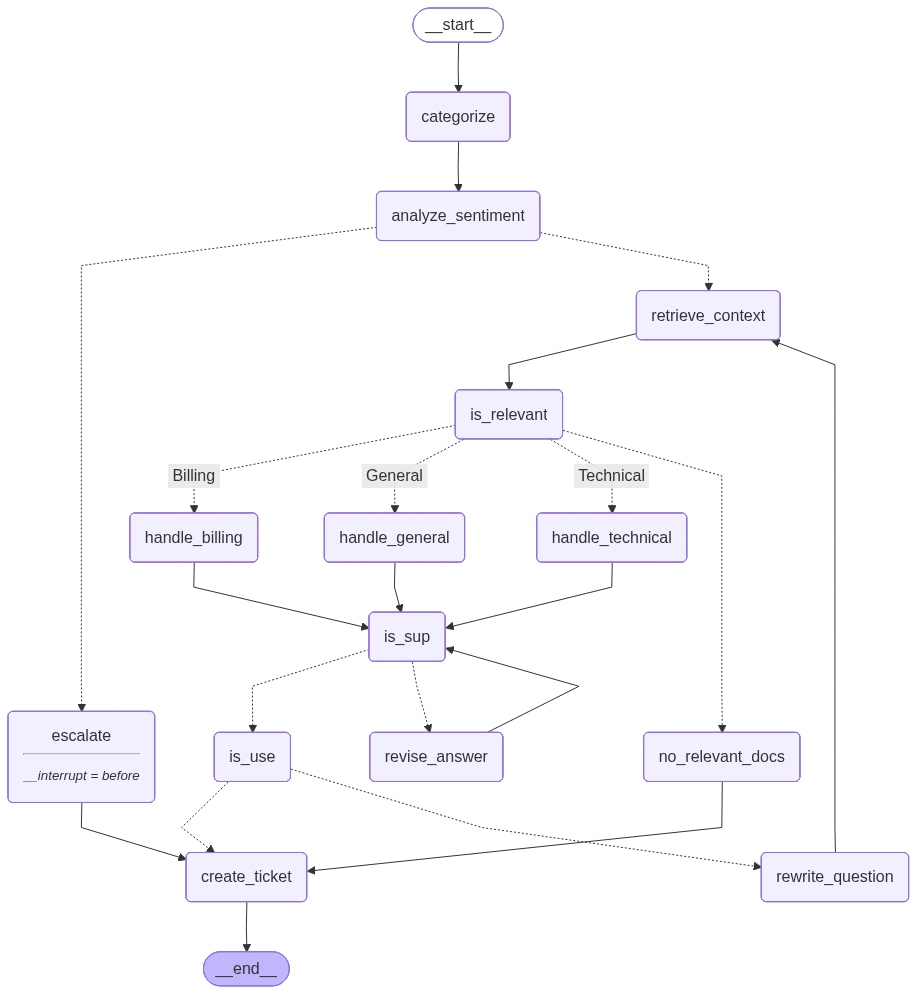

In [12]:
# ── Build graph ───────────────────────────────────────────────────────────────

workflow = StateGraph(State)

# ── Add nodes ─────────────────────────────────────────────────────────────────
workflow.add_node("categorize",       categorize)
workflow.add_node("analyze_sentiment",analyze_sentiment)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("is_relevant",      is_relevant)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing",   handle_billing)
workflow.add_node("handle_general",   handle_general)
workflow.add_node("no_relevant_docs", no_relevant_docs)
workflow.add_node("escalate",         escalate)
workflow.add_node("is_sup",           is_sup)
workflow.add_node("revise_answer",    revise_answer)
workflow.add_node("is_use",           is_use)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("create_ticket",    create_ticket)

# ── Edges ─────────────────────────────────────────────────────────────────────

# Entry
workflow.add_edge(START, "categorize")
workflow.add_edge("categorize", "analyze_sentiment")

# Routing after sentiment
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "escalate":        "escalate",
        "retrieve_context": "retrieve_context",
    }
)

# RAG pipeline
workflow.add_edge("retrieve_context", "is_relevant")

workflow.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "Technical":        "handle_technical",
        "Billing":          "handle_billing",
        "General":          "handle_general",
        "no_relevant_docs": "no_relevant_docs",
    }
)

# All handlers → is_sup
workflow.add_edge("handle_technical",  "is_sup")
workflow.add_edge("handle_billing",    "is_sup")
workflow.add_edge("handle_general",    "is_sup")
workflow.add_edge("no_relevant_docs",  "create_ticket")  # skip verification

# IsSUP loop
workflow.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "is_use":       "is_use",
        "revise_answer": "revise_answer",
    }
)
workflow.add_edge("revise_answer", "is_sup")   # 🔁 loop back

# IsUSE routing
workflow.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "create_ticket":   "create_ticket",
        "rewrite_question": "rewrite_question",
    }
)
workflow.add_edge("rewrite_question", "retrieve_context")  # 🔁 loop back

# Escalation + ticket → END
workflow.add_edge("escalate",     "create_ticket")
workflow.add_edge("create_ticket", END)

# ── Compile with HITL + checkpointer ─────────────────────────────────────────
memory = MemorySaver()
app = workflow.compile(
    checkpointer=memory,
    interrupt_before=["escalate"]
)

app

In [13]:
# ── Run agent helper (with HITL) ──────────────────────────────────────────────

def run_agent(query: str, auto_approve: bool = None) -> dict:
    """
    Run SupportIQ agent.
    - If escalation triggered: pauses and asks for human approval.
    - auto_approve=True/False skips the input prompt (useful for testing).
    Each run is tagged for LangSmith observability.
    """
    thread_config = {
        "configurable": {"thread_id": str(uuid.uuid4())},
        "run_name": "SupportIQ",
        "tags": ["supportiq", "novatech"],
        "metadata": {"query_preview": query[:60]},
    }

    initial_state = {
        "query":             query,
        "category":          "",
        "confidence":        0.0,
        "sentiment":         "",
        "original_sentiment": "",
        "retrieval_query":   "",
        "docs":              [],
        "relevant_docs":     [],
        "context":           "",
        "response":          "",
        "issup":             "",
        "evidence":          [],
        "revise_tries":      0,
        "isuse":             "",
        "use_reason":        "",
        "rewrite_tries":     0,
        "ticket_id":         "",
        "ticket":            {},
    }

    print(f"\n{'='*60}")
    print(f"Query: {query}")
    print(f"{'='*60}")

    result = app.invoke(initial_state, config=thread_config)

    # Check for HITL interrupt
    state = app.get_state(thread_config)
    if "escalate" in state.next:
        print(f"\n{'='*60}")
        print("⚠️  ESCALATION REQUESTED")
        print(f"Category : {state.values['category']}")
        print(f"Sentiment: {state.values['sentiment']}")
        print(f"{'='*60}")

        if auto_approve is not None:
            approval = "yes" if auto_approve else "no"
            print(f"Auto-approve: {approval}")
        else:
            approval = input("\nApprove escalation? (yes/no): ").strip().lower()

        if approval == "yes":
            thread_config["tags"].append("escalated")
            thread_config["metadata"]["resolution_type"] = "escalated"
            result = app.invoke(None, config=thread_config)
        else:
            app.update_state(
                thread_config,
                {"sentiment": "Neutral"},
                as_node="analyze_sentiment"
            )
            thread_config["tags"].append("escalation-overridden")
            thread_config["metadata"]["resolution_type"] = "escalation-overridden"
            result = app.invoke(None, config=thread_config)

    if result:
        thread_config["metadata"].update({
            "category":        result.get("category", ""),
            "sentiment":       result.get("sentiment", ""),
            "resolution_type": result.get("ticket", {}).get("status", ""),
            "issup":           result.get("issup", ""),
            "isuse":           result.get("isuse", ""),
        })

    return result


print("run_agent helper ready ✅")

run_agent helper ready ✅


In [14]:
# ── Test 1: Technical query (password reset) ──────────────────────────────────
result = run_agent("How do I reset my password?")

print(f"\nTicket ID : {result['ticket_id']}")
print(f"Category  : {result['category']}")
print(f"Sentiment : {result['sentiment']}")
print(f"IsSUP     : {result['issup']}")
print(f"IsUSE     : {result['isuse']}")
print(f"Status    : {result['ticket']['status']}")
print(f"\nResponse:\n{result['response']}")


Query: How do I reset my password?
  [is_relevant] 2/4 docs kept
  [is_sup] issup=fully_supported
  [is_use] isuse=useful | reason=The answer provides clear, step-by-step instructions for resetting the password.

Ticket created: NVT-71F91234 | Status: Resolved

Ticket ID : NVT-71F91234
Category  : Technical
Sentiment : Neutral
IsSUP     : fully_supported
IsUSE     : useful
Status    : Resolved

Response:
To reset your password, follow these steps:

1. Visit the NovaTech login page at app.novatech.io.
2. Click on the 'Forgot Password?' link located below the sign-in form.
3. Enter the email address associated with your account and click Submit.

You will receive a password reset email within 2 minutes. Click the link in the email (note that it expires after 30 minutes) and enter your new password. Make sure your new password is at least 8 characters long and includes at least one uppercase letter and one number.


In [15]:
# ── Test 2: Billing query ─────────────────────────────────────────────────────
result = run_agent("What is your refund policy?")

print(f"\nTicket ID : {result['ticket_id']}")
print(f"IsSUP     : {result['issup']}")
print(f"IsUSE     : {result['isuse']}")
print(f"Status    : {result['ticket']['status']}")
print(f"\nResponse:\n{result['response']}")


Query: What is your refund policy?
  [is_relevant] 4/4 docs kept
  [is_sup] issup=fully_supported
  [is_use] isuse=useful | reason=The answer clearly outlines the refund policy, including the time frame and process for requesting a refund.

Ticket created: NVT-CB7F8517 | Status: Resolved

Ticket ID : NVT-CB7F8517
IsSUP     : fully_supported
IsUSE     : useful
Status    : Resolved

Response:
NovaTech offers a 30-day money-back guarantee on all new subscriptions. If you are not satisfied within the first 30 days of your paid subscription, you can request a refund by contacting support at billing@novatech.io with your account email and the reason for your request. Refunds are processed within 5 to 7 business days and credited back to your original payment method. After the 30-day window, refunds are issued on a case-by-case basis at our discretion.


In [16]:
# ── Test 3: HITL escalation — approve ────────────────────────────────────────
result = run_agent(
    "I am absolutely furious. You charged me three times and nobody is helping me!",
    auto_approve=True
)

print(f"\nTicket ID : {result['ticket_id']}")
print(f"Status    : {result['ticket']['status']}")
print(f"Response  : {result['response']}")


Query: I am absolutely furious. You charged me three times and nobody is helping me!

⚠️  ESCALATION REQUESTED
Category : Billing
Sentiment: Negative
Auto-approve: yes

Ticket created: NVT-A88C6838 | Status: Escalated

Ticket ID : NVT-A88C6838
Status    : Escalated
Response  : This query has been escalated to a human agent due to its negative sentiment.


In [ ]:
# ── Test 4: HITL escalation — reject (override to general) ───────────────────
result = run_agent(
    "I am absolutely furious. You charged me three times and nobody is helping me!",
    auto_approve=False
)

print(f"\nTicket ID : {result['ticket_id']}")
print(f"Status    : {result['ticket']['status']}")
print(f"Response  : {result['response']}")

In [ ]:
# ── View all tickets ──────────────────────────────────────────────────────────
tickets = get_all_tickets()
df = pd.DataFrame(tickets)
print(df[[
    "ticket_id", "created_at", "category", "sentiment",
    "issup", "isuse", "revise_tries", "rewrite_tries", "status"
]].to_string(index=False))